# Toxicity Model Training

This notebook starts from `toxicity_all.csv`, applies a clearly editable training filter, builds graph features with taxonomy metadata, trains the model, and then checks the results in a few different ways.


## 1. Setup

Import the training modules and keep the notebook focused on the model pipeline.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import print_mol_types
from src.data.graph_building import build_graph_features
from src.data.taxonomy import encode_taxonomy
from src.data.cleaning import preprocess
from src.training.loops import train
from src.models.attentive_fp import AttentiveFP
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder
from src.visualization.training_plots import plot_toxicity_distribution, plot_training
from src.data.splitting import butina_split, generate_scaffold

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

print("Setup complete")
print(f"Data file: {DATA_PATH}")


/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete
Data file: /home/vollmers/gnn-thesis/Data/toxicity_all.csv


## 2. Load And Filter The Training Slice

The defaults below create a coherent starting dataset for modeling: fish-only, `EC50`, `mg/L`, and hour-based durations. Change these values in this cell when you want a different training subset.


In [ ]:
selected_columns = [
    # "SK_unique_id",
    # "data_source",
    "species_group",
    # "species_latin_name",
    "SMILES",
    "conc",
    "conc_unit",
    # "conc_sign",
    "duration",
    "duration_unit",
    "endpoint",
    "effect",
    "NCBI_rank_class",
    "NCBI_rank_family",
    "NCBI_rank_genus",
    "NCBI_rank_species",
]

# species_groups = ["fish"]
endpoints = ["EC50"]
conc_units = ["mg/L"]
duration_units = ["h"]
require_duration = True
require_taxonomy = True
max_rows = 50000  # set to an integer like 15000 for faster experiments
max_rows = None
random_state = 11

df_all = load_data(DATA_PATH, selected_columns)

mask = (
    df_all["endpoint"].isin(endpoints)
    & df_all["conc_unit"].isin(conc_units)
    # & df_all["conc_sign"].eq("=")
    & df_all["conc"].gt(0)
    & df_all["SMILES"].notna()
)
# print(df_all["endpoint"].isin(endpoints).value_counts(normalize=True).to_string())

if require_duration:
    mask &= df_all["duration"].notna() & df_all["duration_unit"].isin(duration_units)

if require_taxonomy:
    mask &= df_all[["NCBI_rank_class", "NCBI_rank_family", "NCBI_rank_genus", "NCBI_rank_species"]].notna().all(axis=1)

filtered_df = df_all.loc[mask].copy()

if max_rows is not None and len(filtered_df) > max_rows:
    filtered_df = filtered_df.sample(n=max_rows, random_state=random_state).reset_index(drop=True)
else:
    filtered_df = filtered_df.reset_index(drop=True)

for col in ["NCBI_rank_class", "NCBI_rank_family", "NCBI_rank_genus", "NCBI_rank_species"]:
    filtered_df[col] = pd.to_numeric(filtered_df[col], errors="coerce").astype("Int64")

filtered_df = filtered_df.rename(columns={
    "NCBI_rank_species": "taxid",
    "NCBI_rank_genus": "genus",
    "NCBI_rank_family": "family",
    "NCBI_rank_class": "class",
})

print("Loaded and filtered training data")
print(f"Rows in full selected table: {len(df_all):,}")
print(f"Rows after filter: {len(filtered_df):,}")
print()
print("Filters used")
print(f"endpoints = {endpoints}")
# print(f"conc_units = {conc_units}")
print(f"duration_units = {duration_units}")
print(f"require_duration = {require_duration}")
print(f"require_taxonomy = {require_taxonomy}")
print(f"max_rows = {max_rows}")
print()
print("Filtered preview")
print(filtered_df.head())
# print()
# print("Top species in the filtered slice")
# print(filtered_df["species_latin_name"].value_counts().head(12).to_string())
# print()
# print("Duration summary")
# print(filtered_df["duration"].describe().round(2).to_string())


Loaded and filtered training data
Rows in full selected table: 561,100
Rows after filter: 138,272

Filters used
endpoints = ['EC50']
duration_units = ['h']
require_duration = True
require_taxonomy = True
max_rows = None

Filtered preview
  species_group                SMILES    conc conc_unit  duration  \
0       rodents                  CC=O  20.300      mg/L       2.0   
1       rodents  CC1OC(C)OC(C)OC(C)O1   0.348      mg/L       2.0   
2       rodents  CC1OC(C)OC(C)OC(C)O1   0.203      mg/L       4.0   
3       rodents       CCN(CC)C(=O)CCl   0.315      mg/L       4.0   
4       rodents       CCN(CC)C(=O)CCl   0.270      mg/L       2.0   

  duration_unit endpoint effect  class  family  genus  taxid  
0             h     EC50    MOR  40674   10066  10088  10090  
1             h     EC50    MOR  40674   10066  10088  10090  
2             h     EC50    MOR  40674   10066  10114  10116  
3             h     EC50    BEH  40674   10066  10114  10116  
4             h     EC50    BEH 

## 3. Preprocess Molecules And Targets

Apply the molecular cleaning choices here and create the `log10c` target that the model will learn.


In [ ]:
split_salts = False
remove_lone = False
remove_metals = False

processed_df = preprocess(
    filtered_df.copy(),
    split_salts=split_salts,
    remove_lone=remove_lone,
    remove_metals=remove_metals,
)

print(f"Rows before preprocessing: {len(filtered_df):,}")
print(f"Rows after preprocessing:  {len(processed_df):,}")
print(f"Rows removed: {len(filtered_df) - len(processed_df):,}")
print()
print("Preprocessed preview")
print(processed_df[["SMILES", "conc", "log10c", "duration", "species_latin_name"]].head())
print()
print_mol_types(processed_df)


Step 2: Applied preprocessing
Rows before preprocessing: 50,000
Rows after preprocessing:  50,000
Rows removed: 0

Preprocessed preview
                                                            SMILES       conc  \
0                                                 CN1CSC(=S)N(C)C1     0.8800   
1                                                             [Cu]     0.0581   
2                                                         CN(C)C=O  7450.0000   
3  [C-]#N.[C-]#N.[C-]#N.[C-]#N.[C-]#N.[C-]#N.[Fe+3].[K+].[K+].[K+]     2.8000   
4                                         O=S(=O)([O-])[O-].[Zn+2]    60.0000   

     log10c  duration    species_latin_name  
0 -0.055517      24.0         daphnia magna  
1 -1.235824      96.0            e. affinis  
2  3.872156     144.0   pimephales promelas  
3  0.447158      96.0   poecilia reticulata  
4  1.778151      48.0  tanichthys albonubes  



[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not removing hydrogen atom without neighbors
[10:20:58] WARNING: not r

Total molecules: 50000
Unique molecules: 5696
Salts: 11803, 23.61%
Single atoms: 296, 0.59%
Metals: 13303, 26.61%


[10:21:00] WARNING: not removing hydrogen atom without neighbors
[10:21:00] WARNING: not removing hydrogen atom without neighbors
[10:21:01] WARNING: not removing hydrogen atom without neighbors


## 4. Convert Molecules And Encode Taxonomy

Turn the filtered table into molecular graphs and encode the taxonomy columns that the metadata encoder will use.


In [ ]:
processed_df["features"] = processed_df["SMILES"].apply(from_smiles)

embedding_size = {
    "taxid": 16,
    "genus": 8,
    "family": 8,
    "class": 4,
}

taxid_lookup = (
    processed_df[["taxid", "species_latin_name"]]
    .dropna()
    .drop_duplicates()
    .groupby("taxid")["species_latin_name"]
    .first()
    .to_dict()
)

df_tax = processed_df[list(embedding_size.keys())].copy()
df_tax, encoders = encode_taxonomy(df_tax, embedding_size.keys())
config_tax = {
    col: (df_tax[col].nunique() + 1, dim)
    for col, dim in embedding_size.items()
}
taxid_decoder = {encoded: original for original, encoded in encoders["taxid"].items()}

sample_id = min(16, len(processed_df) - 1)
sample_graph = processed_df["features"].iloc[sample_id]

print("Prepared graph inputs and taxonomy encodings")
print(f"Rows with graph features: {len(processed_df):,}")
print(f"Sample index: {sample_id}")
print(f"Sample SMILES: {processed_df.iloc[sample_id]['SMILES']}")
print(f"Nodes: {sample_graph.num_nodes}")
print(f"Edges: {sample_graph.edge_index.shape[1]}")
print(f"Node feature shape: {tuple(sample_graph.x.shape)}")
print(f"Edge feature shape: {tuple(sample_graph.edge_attr.shape)}")
print()
print("Taxonomy embedding config")
print(config_tax)


Step 3: Prepared graph inputs and taxonomy encodings
Rows with graph features: 50,000
Sample index: 16
Sample SMILES: CON=C(C(=O)OC)c1ccccc1CON=C(C)c1cccc(C(F)(F)F)c1
Nodes: 29
Edges: 60
Node feature shape: (29, 9)
Edge feature shape: (60, 3)

Taxonomy embedding config
{'taxid': (2363, 16), 'genus': (1531, 8), 'family': (760, 8), 'class': (93, 4)}


## 5. Build The Final Graph Dataset

Attach the normalized target input columns and taxonomy ids to each PyG graph object.


In [8]:
features = build_graph_features(processed_df, df_tax, embedding_size)

sample_feature = features[sample_id]

print(f"Graph objects created: {len(features):,}")
print(f"Target y (log10c): {sample_feature.y.item():.4f}")
print(f"Duration: {sample_feature.duration.item():.1f}")
print(f"Encoded taxid: {sample_feature.taxid.item()}")
print(f"Encoded genus: {sample_feature.genus.item()}")
print(f"Node matrix shape: {tuple(sample_feature.x.shape)}")
print(f"Edge index shape: {tuple(sample_feature.edge_index.shape)}")


Graph objects created: 50,000
Target y (log10c): -1.0458
Duration: 96.0
Encoded taxid: 15
Encoded genus: 15
Node matrix shape: (29, 9)
Edge index shape: (2, 60)


## 6. Split The Dataset

Use the same split style as before, but keep the split settings in this cell so they are easy to change in context.


In [9]:
split_method = "butina"
frac_train = 0.8
frac_test = 0.2

train_dataset, test_dataset = butina_split(
    features,
    frac_train=frac_train,
    frac_test=frac_test,
)

train_targets_before = np.array([g.y.item() for g in train_dataset])
test_targets_before = np.array([g.y.item() for g in test_dataset])
train_smiles = [g.smiles for g in train_dataset]
test_smiles = [g.smiles for g in test_dataset]
train_taxids = [g.taxid.item() for g in train_dataset]
test_taxids = [g.taxid.item() for g in test_dataset]

print(f"Split method: {split_method}")
print(f"Train fraction: {frac_train}")
print(f"Test fraction:  {frac_test}")
print(f"Train size: {len(train_dataset):,} ({len(train_dataset) / len(features):.1%})")
print(f"Test size:  {len(test_dataset):,} ({len(test_dataset) / len(features):.1%})")
print()
print(f"Unique molecules in train: {len(set(train_smiles)):,}")
print(f"Unique molecules in test:  {len(set(test_smiles)):,}")
print(f"Test molecules not in train: {len(set(test_smiles) - set(train_smiles)):,}")
print()
print(f"Unique encoded taxids in train: {len(set(train_taxids)):,}")
print(f"Unique encoded taxids in test:  {len(set(test_taxids)):,}")
print()
print("Target distribution before normalization")
print(f"Train mean/std: {train_targets_before.mean():.4f} / {train_targets_before.std():.4f}")
print(f"Test mean/std:  {test_targets_before.mean():.4f} / {test_targets_before.std():.4f}")


Split method: butina
Train fraction: 0.8
Test fraction:  0.2
Train size: 39,985 (80.0%)
Test size:  10,015 (20.0%)

Unique molecules in train: 1,985
Unique molecules in test:  4,002
Test molecules not in train: 3,711

Unique encoded taxids in train: 398
Unique encoded taxids in test:  404

Target distribution before normalization
Train mean/std: 0.0792 / 1.7448
Test mean/std:  0.7140 / 1.7249


## 7. Normalize The Target

Normalize with training-set statistics only, then verify the train and test target distributions.


Mean used: 0.0792
Std used:  1.7448

Target distribution after normalization
Train mean/std: -0.0000 / 1.0000
Test mean/std:  0.3638 / 0.9886


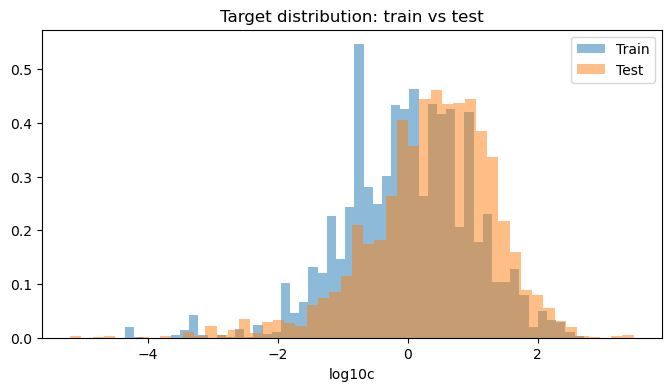

Train mean: -0.00, std: 1.00
Test mean:  0.36,  std: 0.99


In [10]:
target_mean = train_targets_before.mean()
target_std = train_targets_before.std()

for g in train_dataset:
    g.y = (g.y - target_mean) / target_std

for g in test_dataset:
    g.y = (g.y - target_mean) / target_std

train_targets_after = np.array([g.y.item() for g in train_dataset])
test_targets_after = np.array([g.y.item() for g in test_dataset])

print(f"Mean used: {target_mean:.4f}")
print(f"Std used:  {target_std:.4f}")
print()
print("Target distribution after normalization")
print(f"Train mean/std: {train_targets_after.mean():.4f} / {train_targets_after.std():.4f}")
print(f"Test mean/std:  {test_targets_after.mean():.4f} / {test_targets_after.std():.4f}")

plot_toxicity_distribution(train_dataset, test_dataset)


## 8. Build DataLoaders

Create batches and inspect the first batch so the shapes are visible before training starts.


In [11]:
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

first_batch = next(iter(train_loader))

print(f"Batch size: {batch_size}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print()
print("First batch summary")
print(f"Graphs in batch: {first_batch.num_graphs}")
print(f"x shape: {tuple(first_batch.x.shape)}")
print(f"edge_index shape: {tuple(first_batch.edge_index.shape)}")
print(f"edge_attr shape: {tuple(first_batch.edge_attr.shape)}")
print(f"y shape: {tuple(first_batch.y.shape)}")


Batch size: 256
Train batches per epoch: 157
Test batches: 40

First batch summary
Graphs in batch: 256
x shape: (3488, 9)
edge_index shape: (2, 6814)
edge_attr shape: (6814, 3)
y shape: (256,)


## 9. Build The Model

Graph encoder, metadata encoder, and a final toxicity predictor.


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gnn_hidden_dim = 64
gnn_out_dim = 64
meta_hidden_dim = 16
num_layers = 2
num_timesteps = 2
dropout = 0.4
final_hidden_dim = 64

meta_encoder = MetaEncoder(config_tax, hidden_dim=meta_hidden_dim).to(device)
model_gnn = AttentiveFP(
    in_channels=9,
    edge_dim=3,
    hidden_channels=gnn_hidden_dim,
    out_channels=gnn_out_dim,
    num_layers=num_layers,
    num_timesteps=num_timesteps,
    dropout=dropout,
).to(device)
model = ToxicityModel(
    model_gnn,
    meta_encoder,
    gnn_dim=gnn_out_dim,
    encoder_dim=gnn_out_dim + meta_hidden_dim,
    hidden_dim=final_hidden_dim,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device: {device}")
print(f"Trainable parameters: {n_params:,}")
print()
print(model)


Device: cpu
Trainable parameters: 165,213

ToxicityModel(
  (gnn): AttentiveFP(
    (lin1): Linear(in_features=9, out_features=64, bias=True)
    (gate_conv): GATEConv()
    (gru): GRUCell(64, 64)
    (atom_convs): ModuleList(
      (0): GATConv(64, 64, heads=1)
    )
    (atom_grus): ModuleList(
      (0): GRUCell(64, 64)
    )
    (mol_conv): GATConv(64, 64, heads=1)
    (mol_gru): GRUCell(64, 64)
    (lin2): Linear(in_features=64, out_features=64, bias=True)
  )
  (meta_encoder): MetaEncoder(
    (encoder_meta): Sequential(
      (0): Linear(in_features=1, out_features=16, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
    (encoder_tax): TaxonomyEncoder(
      (embeddings): ModuleDict(
        (taxid): Embedding(2363, 16)
        (genus): Embedding(1531, 8)
        (family): Embedding(760, 8)
        (class): Embedding(93, 4)
      )
      (projection): Sequential(
        (0): Linear(in_features=36, out_features=64, bias=True)
        (1): ReLU()
      

## 10. Train The Model

Start with a stable optimizer/scheduler pairing that matches the current training utility.


Step 9: Training configuration
epochs = 200
learning_rate = 0.0003
weight_decay = 0.0001
loss = SmoothL1Loss
Epoch 0: Train Loss = 0.5081, Test Loss = 0.6368
Epoch 10: Train Loss = 0.2186, Test Loss = 0.5711
Epoch 20: Train Loss = 0.1746, Test Loss = 0.6059
Epoch 30: Train Loss = 0.1592, Test Loss = 0.5867
Epoch 40: Train Loss = 0.1479, Test Loss = 0.5497
Epoch 50: Train Loss = 0.1408, Test Loss = 0.5696
Epoch 60: Train Loss = 0.1389, Test Loss = 0.5885
Epoch 70: Train Loss = 0.1344, Test Loss = 0.6111
Epoch 80: Train Loss = 0.1299, Test Loss = 0.5964
Epoch 90: Train Loss = 0.1301, Test Loss = 0.5945
Epoch 100: Train Loss = 0.1257, Test Loss = 0.5608
Epoch 110: Train Loss = 0.1242, Test Loss = 0.5790
Epoch 120: Train Loss = 0.1220, Test Loss = 0.5846
Epoch 130: Train Loss = 0.1243, Test Loss = 0.5629
Epoch 140: Train Loss = 0.1238, Test Loss = 0.5755
Epoch 150: Train Loss = 0.1232, Test Loss = 0.5740
Epoch 160: Train Loss = 0.1255, Test Loss = 0.6010
Epoch 170: Train Loss = 0.1207, Tes

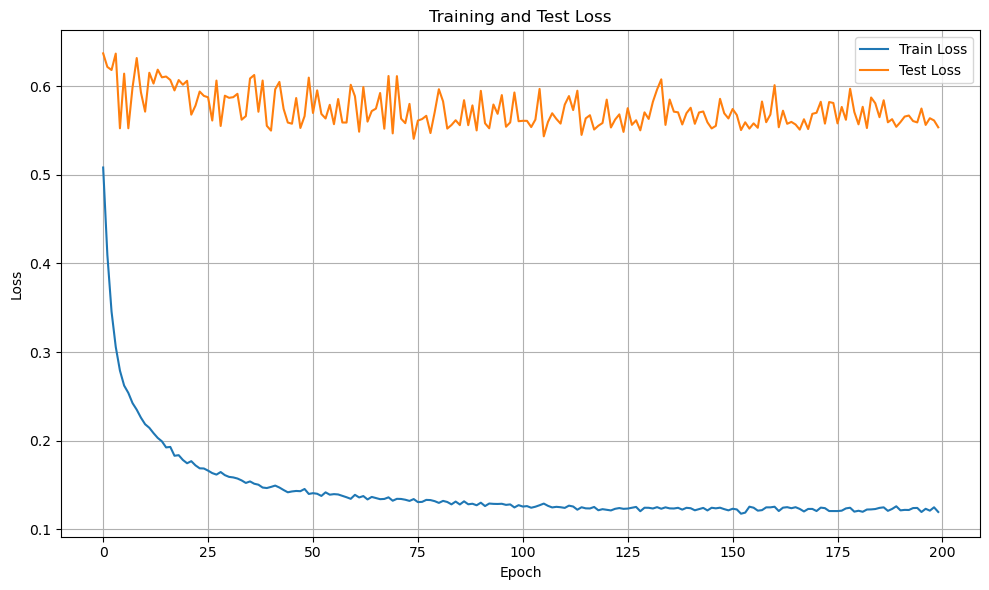

In [14]:
epochs = 200
learning_rate = 3e-4
weight_decay = 1e-4
loss_beta = 0.5

loss_fn = torch.nn.SmoothL1Loss(beta=loss_beta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=15,
    factor=0.5,
    min_lr=1e-6,
)

print("Step 9: Training configuration")
print(f"epochs = {epochs}")
print(f"learning_rate = {learning_rate}")
print(f"weight_decay = {weight_decay}")
print(f"loss = {loss_fn.__class__.__name__}")

model_trained, history = train(
    model,
    train_loader,
    test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=epochs,
    device=device,
)

model = model_trained
plot_training(history)


## 11. Check Overall Test Performance

Report the main metrics and keep both normalized and denormalized outputs available for later inspection.


In [ ]:
preds_norm = []
targets_norm = []
encoded_taxids = []
smiles_test = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch).squeeze()
        preds_norm.extend(pred.cpu().numpy())
        targets_norm.extend(batch.y.cpu().numpy())
        encoded_taxids.extend(batch.taxid.cpu().numpy())
        smiles_test.extend(batch.smiles)

preds_norm = np.array(preds_norm)
targets_norm = np.array(targets_norm)
preds_log10c = preds_norm * target_std + target_mean
targets_log10c = targets_norm * target_std + target_mean

results_df = pd.DataFrame({
    "smiles": smiles_test,
    "pred_norm": preds_norm,
    "actual_norm": targets_norm,
    "pred_log10c": preds_log10c,
    "actual_log10c": targets_log10c,
    "encoded_taxid": encoded_taxids,
})
results_df["taxid"] = results_df["encoded_taxid"].astype(int).map(taxid_decoder)
results_df["species_latin_name"] = results_df["taxid"].map(taxid_lookup)
results_df["pred_conc"] = np.power(10.0, results_df["pred_log10c"])
results_df["actual_conc"] = np.power(10.0, results_df["actual_log10c"])
results_df["abs_error_log10c"] = (results_df["pred_log10c"] - results_df["actual_log10c"]).abs()
results_df["residual_log10c"] = results_df["pred_log10c"] - results_df["actual_log10c"]
results_df["fold_error"] = np.maximum(
    results_df["pred_conc"] / results_df["actual_conc"],
    results_df["actual_conc"] / results_df["pred_conc"],
)

print("Overall test-set metrics")
print(f"R^2 (normalized target): {r2_score(results_df['actual_norm'], results_df['pred_norm']):.3f}")
print(f"R^2 (log10c): {r2_score(results_df['actual_log10c'], results_df['pred_log10c']):.3f}")
print(f"RMSE (log10c): {mean_squared_error(results_df['actual_log10c'], results_df['pred_log10c']) ** 0.5:.3f}")
print(f"MAE (log10c): {mean_absolute_error(results_df['actual_log10c'], results_df['pred_log10c']):.3f}")
print(f"Median fold error (conc scale): {results_df['fold_error'].median():.3f}")
print()
print("Largest errors on the test set")
print(
    results_df[["species_latin_name", "taxid", "actual_log10c", "pred_log10c", "abs_error_log10c", "fold_error", "smiles"]]
    .sort_values("abs_error_log10c", ascending=False)
    .head(10)
    .to_string(index=False)
)


Step 10: Overall test-set metrics
R^2 (normalized target): 0.099
R^2 (log10c): 0.099
RMSE (log10c): 1.637
MAE (log10c): 1.274
Median fold error (conc scale): 10.899

Largest errors on the test set
species_latin_name  taxid  actual_log10c  pred_log10c  abs_error_log10c   fold_error                                           smiles
 Rattus norvegicus  10116      -2.455932   -17.156857         14.700925 5.022554e+14                                  CC(C)OP(C)(=O)F
    eisenia fetida   6396      -8.346787     0.287177          8.633965 4.304917e+08                           O=C(O)COc1ccc2ccccc2c1
     daphnia magna  35525      -9.000000    -0.767469          8.232531 1.708170e+08                               CCCC[Sn](CCCC)CCCC
     daphnia magna  35525      -9.000000    -0.767469          8.232531 1.708170e+08                               CCCC[Sn](CCCC)CCCC
     daphnia magna  35525      -9.000000    -0.767469          8.232531 1.708170e+08                               CCCC[Sn](CCCC)CCCC

## 12. Visual Result Checks

Look at prediction-vs-actual and residual behavior, not just aggregate metrics.


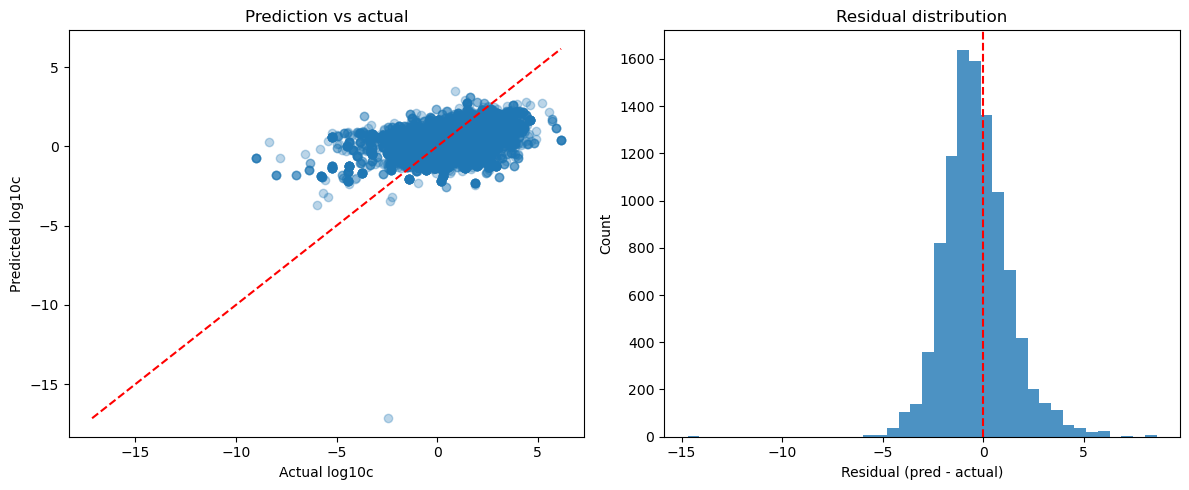

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["actual_log10c"], results_df["pred_log10c"], alpha=0.3)
plot_min = min(results_df["actual_log10c"].min(), results_df["pred_log10c"].min())
plot_max = max(results_df["actual_log10c"].max(), results_df["pred_log10c"].max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set_xlabel("Actual log10c")
axes[0].set_ylabel("Predicted log10c")
axes[0].set_title("Prediction vs actual")

axes[1].hist(results_df["residual_log10c"], bins=40, alpha=0.8)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred - actual)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


## 13. Grouped Checks After Training

Check whether performance changes by scaffold or by species so the model is not only good on average.


In [ ]:
results_df["scaffold"] = results_df["smiles"].apply(generate_scaffold)

scaffold_summary = results_df.groupby("scaffold").apply(
    lambda g: pd.Series({
        "n": len(g),
        "r2": r2_score(g["actual_log10c"], g["pred_log10c"]) if len(g) > 1 else np.nan,
        "mae_log10c": mean_absolute_error(g["actual_log10c"], g["pred_log10c"]),
    })
).sort_values(["n", "mae_log10c"], ascending=[False, True])

species_summary = results_df.dropna(subset=["taxid"]).groupby(["taxid", "species_latin_name"]).apply(
    lambda g: pd.Series({
        "n": len(g),
        "r2": r2_score(g["actual_log10c"], g["pred_log10c"]) if len(g) > 1 else np.nan,
        "mae_log10c": mean_absolute_error(g["actual_log10c"], g["pred_log10c"]),
    })
).sort_values(["n", "mae_log10c"], ascending=[False, True])

print("Scaffold summary")
print(scaffold_summary.head(15).to_string())
print()
print("Species summary")
print(species_summary.head(15).to_string())


/tmp/ipykernel_1685639/928478231.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scaffold_summary = results_df.groupby("scaffold").apply(


Step 11: Scaffold summary
                            n         r2  mae_log10c
scaffold                                            
c1ccccc1               1608.0   0.067259    1.091915
C1CCCCC1                158.0  -0.059437    1.259662
c1ccncc1                124.0   0.056427    1.735621
c1ccc2ccccc2c1           91.0  -0.029439    0.911078
c1ccc(Cc2ccccc2)cc1      84.0   0.011731    0.802890
C1CO1                    65.0  -0.058375    1.035200
c1ccc(-c2ccccc2)cc1      56.0   0.310066    0.353133
c1ccc(Oc2ccccc2)cc1      53.0  -0.013081    0.960055
C1=CCCCC1                50.0   0.116366    1.890739
c1ccc(Nc2ccccc2)cc1      47.0   0.012808    1.653702
O=C(c1ccccc1)c1ccccc1    42.0  -0.291684    1.071968
c1ncncn1                 39.0  -0.116305    1.263506
c1ccc2scnc2c1            38.0  -0.121250    1.387137
O=c1ccs[nH]1             37.0 -12.105425    1.838841
c1ccc(N=Nc2ccccc2)cc1    35.0  -1.368437    1.391028

Step 12: Species summary
                                           n   

/tmp/ipykernel_1685639/928478231.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  species_summary = results_df.dropna(subset=["taxid"]).groupby(["taxid", "species_latin_name"]).apply(
